# Dataset Analysis

**Purpose of Step 1**

This notebook verifies that the multispectral imagery, DEM, and masks are readable, spatially aligned, and suitable for downstream segmentation. It also quantifies class imbalance and creates report-ready visualizations.

**Inputs**
- `multi/*.tif`
- `dem/*.tif`
- `masks/*.tif`
- `osm/*.geojson` (optional source inspection)

**Outputs**
- metadata tables
- alignment checks
- RGB / DEM / mask visualizations
- class imbalance statistics
- early NDWI quick-look

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
import geopandas as gpd

### Set paths

In [2]:
from pathlib import Path

cwd = Path.cwd()
print("Current working directory:", cwd)

# Try a few likely locations automatically
candidate_dirs = [
    cwd / "FRS 2026. Floods Monitoring",
    cwd.parent / "FRS 2026. Floods Monitoring",
    cwd / "flood-segmentation" / "FRS 2026. Floods Monitoring",
    cwd.parent / "flood-segmentation" / "FRS 2026. Floods Monitoring",
]

DATA_DIR = None
for p in candidate_dirs:
    if p.exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find 'FRS 2026. Floods Monitoring'. "
        f"Tried: {[str(p) for p in candidate_dirs]}"
    )

MULTI_DIR = DATA_DIR / "multi"
DEM_DIR = DATA_DIR / "dem"
MASK_DIR = DATA_DIR / "masks"
OSM_DIR = DATA_DIR / "osm"

GEOJSON_FILES = sorted(OSM_DIR.glob("*.geojson"))

print("Resolved DATA_DIR :", DATA_DIR)
print("Multi dir exists  :", MULTI_DIR.exists())
print("DEM dir exists    :", DEM_DIR.exists())
print("Mask dir exists   :", MASK_DIR.exists())
print("OSM dir exists    :", OSM_DIR.exists())
print("GeoJSON files     :", [p.name for p in GEOJSON_FILES])

Current working directory: c:\Users\wattd\OneDrive\Desktop\flood-segmentation
Resolved DATA_DIR : c:\Users\wattd\OneDrive\Desktop\flood-segmentation\FRS 2026. Floods Monitoring
Multi dir exists  : True
DEM dir exists    : True
Mask dir exists   : True
OSM dir exists    : True
GeoJSON files     : ['11-12.geojson', '3-4.geojson', '9-10.geojson']


### List files

In [3]:
def numeric_stem_key(path_obj):
    stem = path_obj.stem
    m = re.match(r"^(\d+)", stem)
    return (int(m.group(1)) if m else float("inf"), stem)

import re

multi_files = sorted(MULTI_DIR.glob("*.tif"), key=numeric_stem_key)
dem_files = sorted(DEM_DIR.glob("*.tif"), key=numeric_stem_key)
mask_files = sorted(MASK_DIR.glob("*.tif"), key=numeric_stem_key)

print("Number of multi files:", len(multi_files))
print("Number of dem files  :", len(dem_files))
print("Number of mask files :", len(mask_files))

print("\nFirst 5 multi files:")
for f in multi_files[:5]:
    print(" ", f.name)

print("\nFirst 10 dem files:")
for f in dem_files[:10]:
    print(" ", f.name)

print("\nFirst 10 mask files:")
for f in mask_files[:10]:
    print(" ", f.name)

Number of multi files: 12
Number of dem files  : 16
Number of mask files : 16

First 5 multi files:
  1.tif
  2.tif
  3.tif
  4.tif
  5.tif

First 10 dem files:
  1.tif
  1_train.tif
  1_val.tif
  2.tif
  2_train.tif
  2_val.tif
  3.tif
  4.tif
  5.tif
  6.tif

First 10 mask files:
  1.tif
  1_train.tif
  1_val.tif
  2.tif
  2_train.tif
  2_val.tif
  3.tif
  4.tif
  5.tif
  6.tif


### Inspect one multispectral raster

In [4]:
multi_path = MULTI_DIR / "1.tif"

with rasterio.open(multi_path) as src:
    print("MULTI FILE :", multi_path.name)
    print("Bands      :", src.count)
    print("Height     :", src.height)
    print("Width      :", src.width)
    print("CRS        :", src.crs)
    print("Transform  :", src.transform)
    print("Dtype      :", src.dtypes)

    multi_data = src.read()
    print("Array shape:", multi_data.shape)

    for b in range(src.count):
        band = multi_data[b]
        print(f"Band {b+1}: min={band.min()}, max={band.max()}, mean={band.mean():.3f}, std={band.std():.3f}")

MULTI FILE : 1.tif
Bands      : 10
Height     : 4971
Width      : 10632
CRS        : EPSG:4326
Transform  : | 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|
Dtype      : ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
Array shape: (10, 4971, 10632)
Band 1: min=0, max=18744, mean=617.148, std=156.799
Band 2: min=0, max=17624, mean=773.923, std=176.527
Band 3: min=35, max=16808, mean=872.885, std=228.391
Band 4: min=0, max=16508, mean=1123.521, std=230.155
Band 5: min=0, max=16289, mean=1515.701, std=436.957
Band 6: min=0, max=16150, mean=1659.978, std=500.476
Band 7: min=3, max=16072, mean=1746.873, std=521.696
Band 8: min=0, max=15593, mean=1794.614, std=514.171
Band 9: min=49, max=15238, mean=2387.270, std=363.981
Band 10: min=0, max=15146, mean=2036.937, std=461.998


### Inspect one DEM raster

In [5]:
dem_path = DEM_DIR / "1.tif"

with rasterio.open(dem_path) as src:
    print("DEM FILE   :", dem_path.name)
    print("Bands      :", src.count)
    print("Height     :", src.height)
    print("Width      :", src.width)
    print("CRS        :", src.crs)
    print("Transform  :", src.transform)
    print("Dtype      :", src.dtypes)

    dem_data = src.read(1)
    print("DEM shape  :", dem_data.shape)
    print(f"DEM stats  : min={dem_data.min()}, max={dem_data.max()}, mean={dem_data.mean():.3f}, std={dem_data.std():.3f}")

DEM FILE   : 1.tif
Bands      : 1
Height     : 4971
Width      : 10632
CRS        : EPSG:4326
Transform  : | 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|
Dtype      : ('float32',)
DEM shape  : (4971, 10632)
DEM stats  : min=71.9272689819336, max=361.0921630859375, mean=157.128, std=42.069


### Inspect one mask raster

In [6]:
mask_path = MASK_DIR / "1.tif"

with rasterio.open(mask_path) as src:
    print("MASK FILE  :", mask_path.name)
    print("Bands      :", src.count)
    print("Height     :", src.height)
    print("Width      :", src.width)
    print("CRS        :", src.crs)
    print("Transform  :", src.transform)
    print("Dtype      :", src.dtypes)

    mask_data = src.read(1)
    print("Mask shape :", mask_data.shape)
    print("Unique vals:", np.unique(mask_data))

MASK FILE  : 1.tif
Bands      : 1
Height     : 4971
Width      : 10632
CRS        : EPSG:4326
Transform  : | 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|
Dtype      : ('uint8',)
Mask shape : (4971, 10632)
Unique vals: [0 1]


### Metadata Summary Tables

In [7]:
def inspect_raster(path):
    with rasterio.open(path) as src:
        return {
            "file": path.name,
            "bands": src.count,
            "height": src.height,
            "width": src.width,
            "crs": str(src.crs),
            "dtype": str(src.dtypes[0]),
            "res_x": src.transform.a,
            "res_y": abs(src.transform.e)
        }

multi_files = sorted(MULTI_DIR.glob("*.tif"))
dem_files = sorted(DEM_DIR.glob("*.tif"))
mask_files = sorted(MASK_DIR.glob("*.tif"))

multi_info = pd.DataFrame([inspect_raster(p) for p in multi_files])
dem_info = pd.DataFrame([inspect_raster(p) for p in dem_files])
mask_info = pd.DataFrame([inspect_raster(p) for p in mask_files])

print("MULTI INFO")
display(multi_info)

print("DEM INFO")
display(dem_info)

print("MASK INFO")
display(mask_info)

MULTI INFO


,file,bands,height,width,crs,dtype,res_x,res_y
0,1.tif,10,4971,10632,EPSG:4326,uint16,0.000140,0.000092
1,10.tif,10,512,512,EPSG:4326,uint16,0.000163,0.000088
2,11.tif,10,768,768,EPSG:4326,uint16,0.000158,0.000088
3,12.tif,10,768,768,EPSG:4326,uint16,0.000158,0.000088
4,2.tif,10,4971,10632,EPSG:4326,uint16,0.000140,0.000092
5,3.tif,10,512,512,EPSG:4326,uint16,0.000146,0.000088
6,4.tif,10,512,512,EPSG:4326,uint16,0.000146,0.000088
7,5.tif,10,4956,2560,EPSG:4326,uint16,0.000163,0.000088
8,6.tif,10,4956,2560,EPSG:4326,uint16,0.000163,0.000088
9,7.tif,10,4911,2456,EPSG:4326,uint16,0.000158,0.000088


DEM INFO


,file,bands,height,width,crs,dtype,res_x,res_y
0,1.tif,1,4971,10632,EPSG:4326,float32,0.000140,0.000092
1,10.tif,1,512,512,EPSG:4326,float32,0.000163,0.000088
2,11.tif,1,768,768,EPSG:4326,float32,0.000158,0.000088
3,12.tif,1,768,768,EPSG:4326,float32,0.000158,0.000088
4,1_train.tif,1,4971,7442,EPSG:4326,float32,0.000140,0.000092
5,1_val.tif,1,4971,3190,EPSG:4326,float32,0.000140,0.000092
6,2.tif,1,4971,10632,EPSG:4326,float32,0.000140,0.000092
7,2_train.tif,1,4971,7442,EPSG:4326,float32,0.000140,0.000092
8,2_val.tif,1,4971,3190,EPSG:4326,float32,0.000140,0.000092
9,3.tif,1,512,512,EPSG:4326,float32,0.000146,0.000088


MASK INFO


,file,bands,height,width,crs,dtype,res_x,res_y
0,1.tif,1,4971,10632,EPSG:4326,uint8,0.000140,0.000092
1,10.tif,1,512,512,EPSG:4326,uint8,0.000163,0.000088
2,11.tif,1,768,768,EPSG:4326,uint8,0.000158,0.000088
3,12.tif,1,768,768,EPSG:4326,uint8,0.000158,0.000088
4,1_train.tif,1,4971,7442,EPSG:4326,uint8,0.000140,0.000092
5,1_val.tif,1,4971,3190,EPSG:4326,uint8,0.000140,0.000092
6,2.tif,1,4971,10632,EPSG:4326,uint8,0.000140,0.000092
7,2_train.tif,1,4971,7442,EPSG:4326,uint8,0.000140,0.000092
8,2_val.tif,1,4971,3190,EPSG:4326,uint8,0.000140,0.000092
9,3.tif,1,512,512,EPSG:4326,uint16,0.000146,0.000088


### Optional GeoJSON source inspection

GeoJSON files found:
  11-12.geojson
  3-4.geojson
  9-10.geojson

Inspecting: 11-12.geojson
Number of features: 21447
CRS: EPSG:4326
Columns: ['type', 'id', 'tags', 'geometry']


,type,id,tags,geometry
0,way,893903344,yes,"POLYGON ((100.56234 54.52816, 100.56244 54.528..."
1,way,893903345,yes,"POLYGON ((100.5631 54.52867, 100.56297 54.5285..."
2,way,893903346,yes,"POLYGON ((100.56322 54.52907, 100.56312 54.528..."
3,way,893903347,yes,"POLYGON ((100.56259 54.52932, 100.56283 54.529..."
4,way,893903339,yes,"POLYGON ((100.5626 54.5302, 100.5625 54.5301, ..."


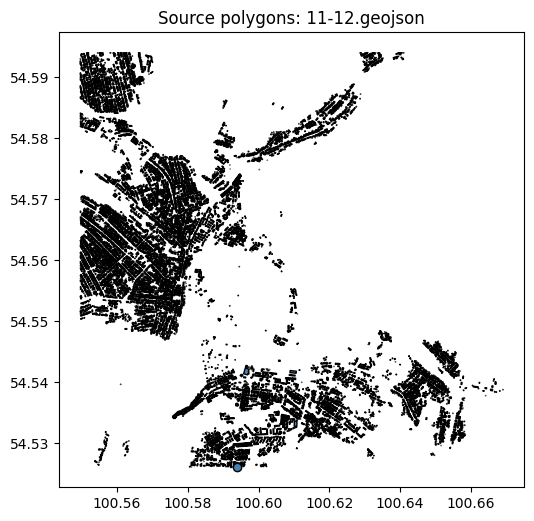

In [8]:
print("GeoJSON files found:")
for gj in GEOJSON_FILES:
    print(" ", gj.name)

if len(GEOJSON_FILES) > 0:
    gj_path = GEOJSON_FILES[0]
    gdf = gpd.read_file(gj_path)

    print(f"\nInspecting: {gj_path.name}")
    print("Number of features:", len(gdf))
    print("CRS:", gdf.crs)
    print("Columns:", list(gdf.columns))
    display(gdf.head())

    fig, ax = plt.subplots(figsize=(6, 6))
    gdf.plot(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Source polygons: {gj_path.name}")
    plt.show()
else:
    print("No GeoJSON files found.")

### Alignment checks

In [9]:
with rasterio.open(multi_path) as msrc, rasterio.open(dem_path) as dsrc, rasterio.open(mask_path) as lsrc:
    print("MULTI vs DEM CRS match :", msrc.crs == dsrc.crs)
    print("MULTI vs MASK CRS match:", msrc.crs == lsrc.crs)

    print("\nMULTI shape:", (msrc.height, msrc.width))
    print("DEM shape  :", (dsrc.height, dsrc.width))
    print("MASK shape :", (lsrc.height, lsrc.width))

    print("\nMULTI resolution:", (msrc.transform.a, abs(msrc.transform.e)))
    print("DEM resolution  :", (dsrc.transform.a, abs(dsrc.transform.e)))
    print("MASK resolution :", (lsrc.transform.a, abs(lsrc.transform.e)))

    print("\nMULTI transform:")
    print(msrc.transform)
    print("\nDEM transform:")
    print(dsrc.transform)
    print("\nMASK transform:")
    print(lsrc.transform)

MULTI vs DEM CRS match : True
MULTI vs MASK CRS match: True

MULTI shape: (4971, 10632)
DEM shape  : (4971, 10632)
MASK shape : (4971, 10632)

MULTI resolution: (0.00014036738148984164, 9.233293099980036e-05)
DEM resolution  : (0.00014036738148984164, 9.233293099980036e-05)
MASK resolution : (0.00014036738148984164, 9.233293099980036e-05)

MULTI transform:
| 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|

DEM transform:
| 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|

MASK transform:
| 0.00, 0.00, 54.99|
| 0.00,-0.00, 51.83|
| 0.00, 0.00, 1.00|


### RGB visualization helper

In [10]:
def read_rgb_for_display(path, r_idx=1, g_idx=2, b_idx=3):
    with rasterio.open(path) as src:
        r = src.read(r_idx).astype(np.float32)
        g = src.read(g_idx).astype(np.float32)
        b = src.read(b_idx).astype(np.float32)

    rgb = np.stack([r, g, b], axis=-1)

    rgb_disp = np.zeros_like(rgb, dtype=np.float32)
    for i in range(3):
        p2, p98 = np.percentile(rgb[..., i], (2, 98))
        rgb_disp[..., i] = np.clip((rgb[..., i] - p2) / (p98 - p2 + 1e-8), 0, 1)

    return rgb_disp

### RGB visualization

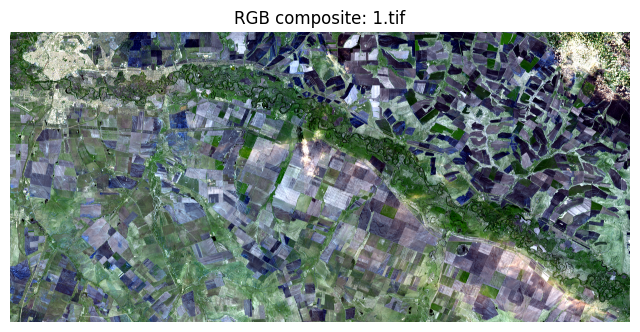

In [11]:
rgb_display = read_rgb_for_display(multi_path)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title(f"RGB composite: {multi_path.name}")
plt.axis("off")
plt.show()

### DEM visualization

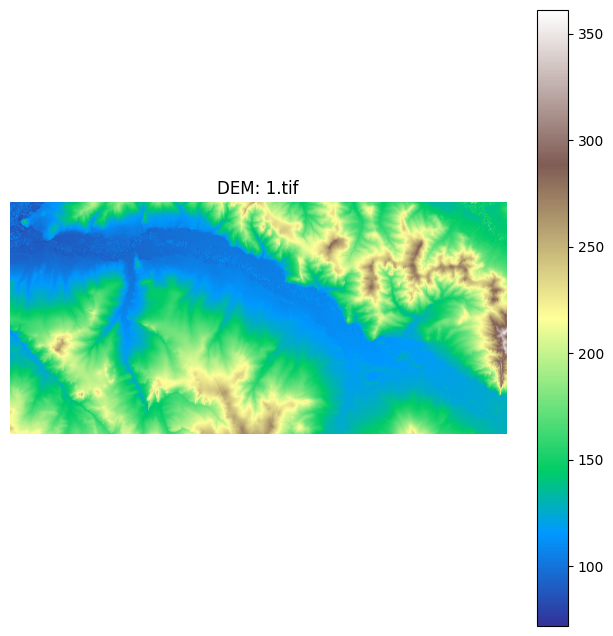

In [12]:
with rasterio.open(dem_path) as src:
    dem_display = src.read(1).astype(np.float32)

plt.figure(figsize=(8, 8))
plt.imshow(dem_display, cmap="terrain")
plt.title(f"DEM: {dem_path.name}")
plt.colorbar()
plt.axis("off")
plt.show()

### Mask visualization

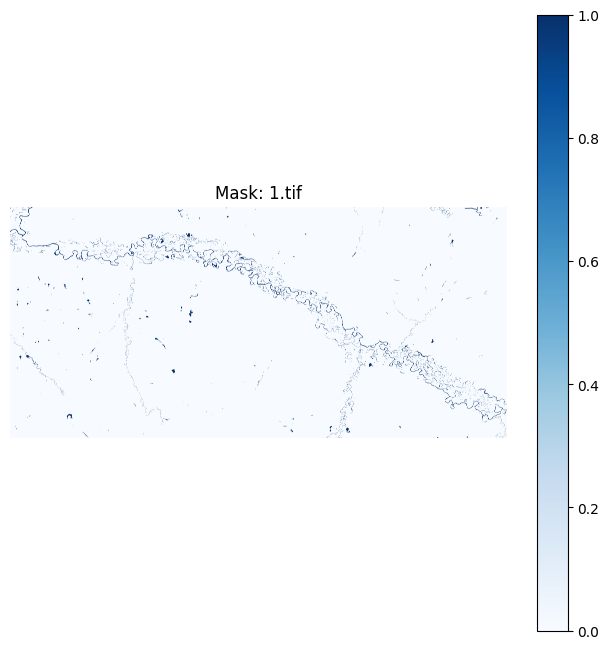

In [13]:
with rasterio.open(mask_path) as src:
    mask_display = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(mask_display, cmap="Blues")
plt.title(f"Mask: {mask_path.name}")
plt.colorbar()
plt.axis("off")
plt.show()

### RGB + mask overlay

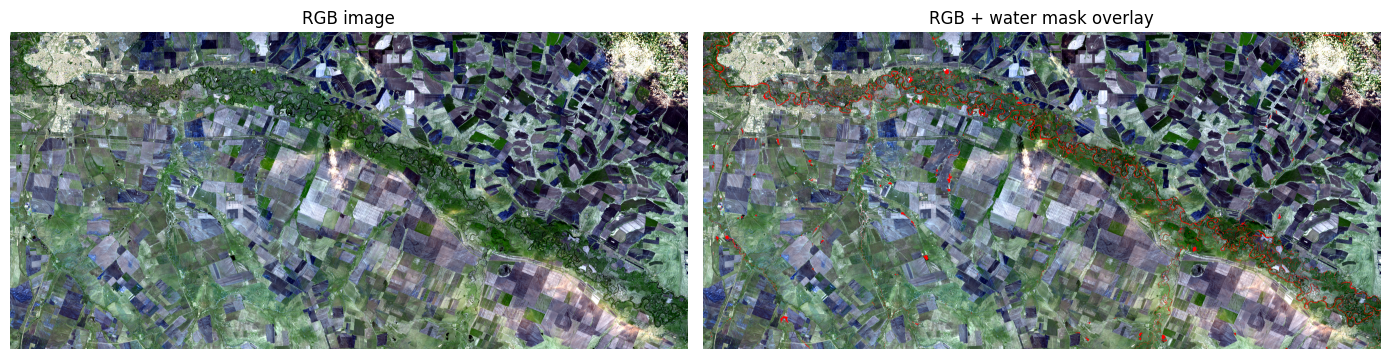

In [14]:
overlay = rgb_display.copy()

# make sure mask is binary
mask_binary = (mask_display > 0).astype(np.uint8)

# overlay water in red
overlay[mask_binary == 1] = [1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb_display)
axes[0].set_title("RGB image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("RGB + water mask overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Class imbalance statistics

In [15]:
num_water = np.sum(mask_binary == 1)
num_nonwater = np.sum(mask_binary == 0)
total = mask_binary.size

water_pct = 100 * num_water / total
nonwater_pct = 100 * num_nonwater / total

print(f"Water pixels    : {num_water}")
print(f"Non-water pixels: {num_nonwater}")
print(f"Water %         : {water_pct:.3f}")
print(f"Non-water %     : {nonwater_pct:.3f}")

Water pixels    : 675055
Non-water pixels: 52176617
Water %         : 1.277
Non-water %     : 98.723


### Compute NDWI for an early feature check

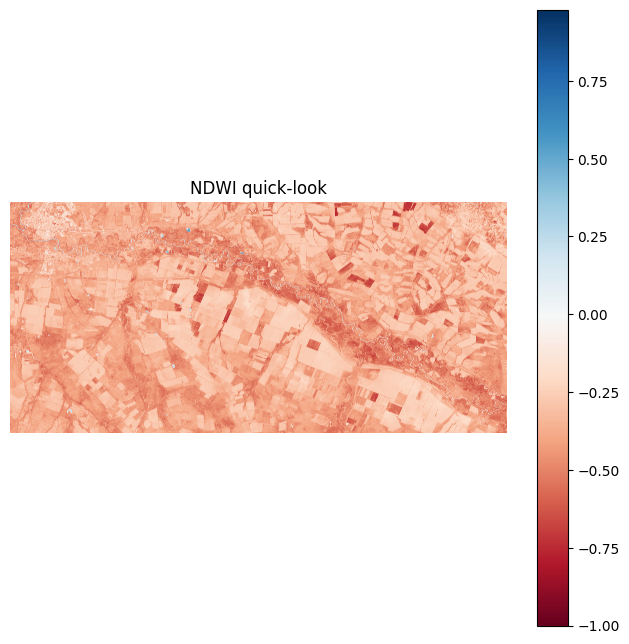

In [16]:
with rasterio.open(multi_path) as src:
    green = src.read(2).astype(np.float32)   # B03
    nir = src.read(7).astype(np.float32)     # B08

ndwi = (green - nir) / (green + nir + 1e-8)

plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="RdBu")
plt.title("NDWI quick-look")
plt.colorbar()
plt.axis("off")
plt.show()

### Combined figure for the report

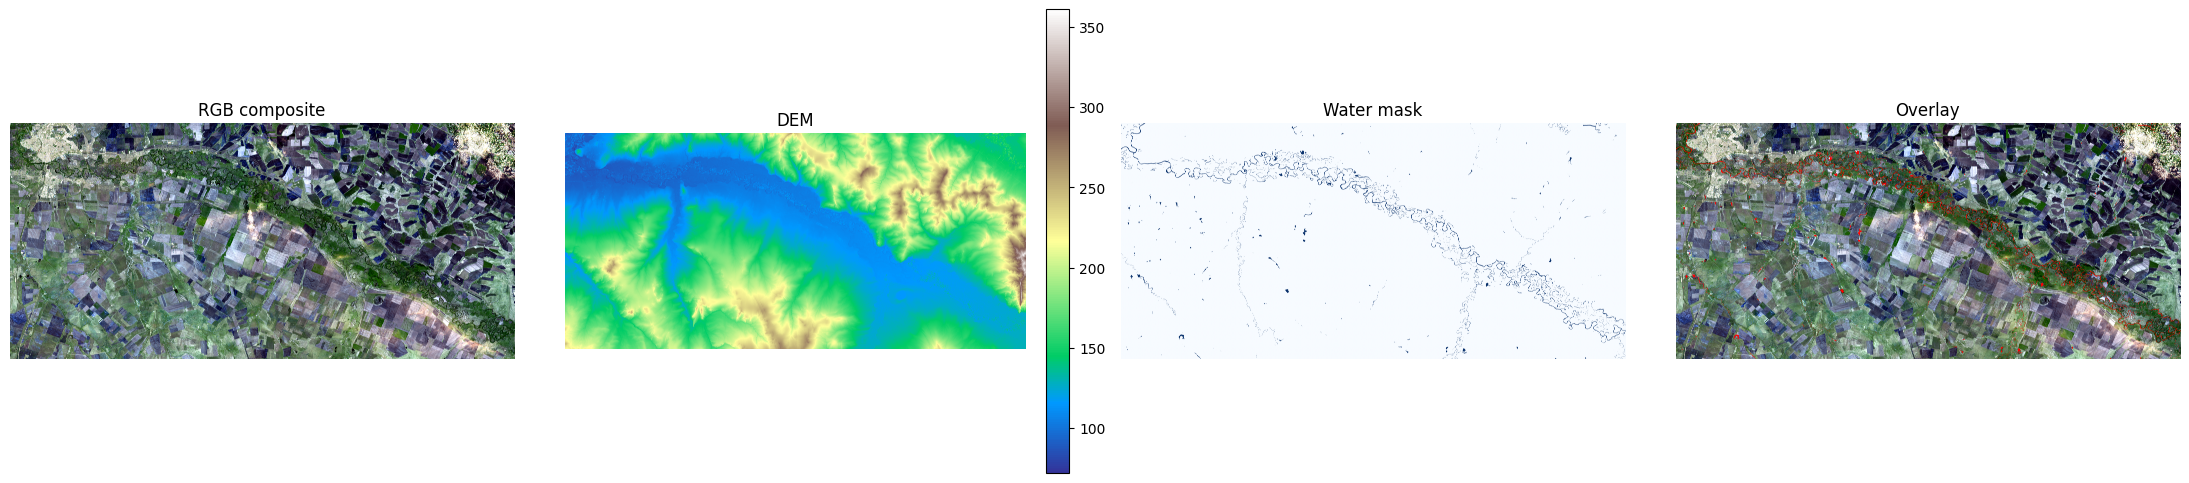

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(rgb_display)
axes[0].set_title("RGB composite")
axes[0].axis("off")

im1 = axes[1].imshow(dem_display, cmap="terrain")
axes[1].set_title("DEM")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(mask_binary, cmap="Blues")
axes[2].set_title("Water mask")
axes[2].axis("off")

axes[3].imshow(overlay)
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

Actual Band Labels:
Band 1 = B02
Band 2 = B03
Band 3 = B04
Band 4 = B05
Band 5 = B06
Band 6 = B07
Band 7 = B08
Band 8 = B8A
Band 9 = B11
Band 10 = B12

### Final dataset split used in this project
- Training scenes: `1_train`, `2_train`
- Validation scenes: `1_val`, `2_val`
- Test scenes: `3`–`12`

### Dataset Conclusions

1. The dataset contains **10-band multispectral imagery**, **DEM**, and **binary flood/water masks**.
2. For the inspected scene, the multispectral image, DEM, and mask are fully aligned in **CRS, transform, spatial resolution, and raster dimensions**.
3. The binary masks appear visually consistent with the river/flooded regions visible in the multispectral composite.
4. The scene shows **strong class imbalance**, with water pixels occupying only a small fraction of the total area.
5. This motivates the later use of **imbalance-aware losses** and reliable segmentation metrics such as **F1, IoU, Precision, and Recall**.
6. The optional GeoJSON inspection confirms that polygon-based source annotations are available, even though the main training pipeline will use the raster masks directly.
7. The provided dataset is already spatially harmonized, since multispectral rasters, DEM, and masks share the same CRS, transform, shape, and pixel resolution.